# Évaluation GBS v7 — Données 2023-2025 (Protocole Jury Officiel)

**Différence vs v6 :** ajout de `airport_enc` (LabelEncoder aéroport)

**Métriques calculées :**
- **Risk R = M^L3 / N^L3** : fraction des éclairs < 3 km manqués
- **Gain G** : heures économisées vs règle fixe 30 min
- **θ optimal** : seuil maximisant G sous contrainte R < 2%
- Comparaison directe v6 vs v7

In [1]:
import sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

ROOT     = Path('../')
DIST_3KM = 3.0
R_MAX    = 0.02

# Modèle v7
MODEL_PATH  = ROOT / 'models' / 'gbs_v7_model.pkl'
SCALER_PATH = ROOT / 'models' / 'gbs_v7_scaler.pkl'
LE_PATH     = ROOT / 'models' / 'gbs_v7_label_encoder.pkl'
META_PATH   = ROOT / 'models' / 'gbs_v7_metadata.json'

FEATURES_V6 = [
    'h_cos', 'h_sin', 'doy_cos', 'doy_sin', 'saison',
    'dist_centre', 'dist_avg_5', 'dist_min_so_far',
    'silence_min', 'freq_5min', 'rang', 'rang_norm',
]
FEATURES_V7 = FEATURES_V6 + ['airport_enc']

print('Features v7 :', FEATURES_V7)
print('N features  :', len(FEATURES_V7))

Features v7 : ['h_cos', 'h_sin', 'doy_cos', 'doy_sin', 'saison', 'dist_centre', 'dist_avg_5', 'dist_min_so_far', 'silence_min', 'freq_5min', 'rang', 'rang_norm', 'airport_enc']
N features  : 13


## 1. Chargement modèle + données

In [2]:
gbs    = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
le     = joblib.load(LE_PATH)
with open(META_PATH) as f:
    meta = json.load(f)

print(f"GBS v7")
print(f"  C-index train          : {meta['c_index_train']:.4f}")
print(f"  C-index test (2021-22) : {meta['c_index_test']:.4f}")
print(f"  Δ vs v6                : {meta['delta_test']:+.4f}")
print(f"  Aéroports encodés      : {list(zip(le.classes_, le.transform(le.classes_)))}")

GBS v7
  C-index train          : 0.7756
  C-index test (2021-22) : 0.7421
  Δ vs v6                : +0.0011
  Aéroports encodés      : [('Ajaccio', np.int64(0)), ('Bastia', np.int64(1)), ('Biarritz', np.int64(2)), ('Nantes', np.int64(3)), ('Pise', np.int64(4))]


In [3]:
df_raw = pd.read_csv(ROOT / 'segment_alerts_all_airports_eval.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'], utc=True)

print(f'Total CSV         : {len(df_raw):,}')
print(f'Avec alert_id     : {df_raw["alert_id"].notna().sum():,}')
print(f'Éclairs < 3km     : {(df_raw["dist"] < 3.0).sum():,}')
print(f'Années            : {sorted(df_raw["date"].dt.year.unique())}')

df = df_raw[df_raw['alert_id'].notna()].copy()
df = df.rename(columns={'alert_id': 'airport_alert_id'})
df = df.sort_values(['airport', 'airport_alert_id', 'date']).reset_index(drop=True)

n_alerts = df['airport_alert_id'].nunique()
N_L3     = int((df['dist'] < DIST_3KM).sum())

print(f'\nStrikes dans alertes : {len(df):,}')
print(f'Alertes uniques      : {n_alerts:,}')
print(f'N_L3 (éclairs <3km)  : {N_L3:,}')
print(f'\nAlertes par aéroport :')
print(df.groupby('airport')['airport_alert_id'].nunique().to_string())

# Vérifier que les aéroports du jeu eval sont connus du label encoder
airports_eval = set(df['airport'].unique())
airports_train = set(le.classes_)
unknown = airports_eval - airports_train
print(f'\nAéroports inconnus du LabelEncoder : {unknown if unknown else "aucun ✓"}')

Total CSV         : 188,175
Avec alert_id     : 80,186
Éclairs < 3km     : 1,995
Années            : [np.int32(2023), np.int32(2024), np.int32(2025)]

Strikes dans alertes : 80,186
Alertes uniques      : 1,352
N_L3 (éclairs <3km)  : 1,995

Alertes par aéroport :
airport
Ajaccio     256
Bastia      322
Biarritz    313
Nantes      122
Pise        339

Aéroports inconnus du LabelEncoder : aucun ✓


## 2. Feature Engineering — IDENTIQUE v6 + airport_enc

In [4]:
t0 = time.time()

g = df.groupby(['airport', 'airport_alert_id'])

# ── Features V6 (identiques) ─────────────────────────────────────
h = df['date'].dt.hour + df['date'].dt.minute / 60
df['h_cos']   = np.cos(2 * np.pi * h / 24)
df['h_sin']   = np.sin(2 * np.pi * h / 24)
doy = df['date'].dt.dayofyear
df['doy_cos'] = np.cos(2 * np.pi * doy / 365)
df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
df['saison']  = ((df['date'].dt.month % 12) // 3) + 1

prev = g['date'].shift(1)
df['silence_min'] = ((df['date'] - prev).dt.total_seconds() / 60).fillna(30).clip(0, 60)
df['freq_5min']   = (1 / df['silence_min'].clip(lower=0.5)).clip(upper=10)

df['dist_centre']     = df['dist']
df['dist_avg_5']      = g['dist'].transform(lambda x: x.rolling(5, min_periods=1).mean())
df['dist_min_so_far'] = g['dist'].cummin()

df['rang']      = g.cumcount()
df['rang_norm'] = df['rang'] / g['rang'].transform('max').clip(lower=1)

# ── Feature V7 : airport_enc ─────────────────────────────────────
# Utiliser le LabelEncoder fitté sur le TRAIN (pas de refit sur les données eval)
df['airport_enc'] = le.transform(df['airport'])

# Imputation
for col in FEATURES_V7:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

missing = [c for c in FEATURES_V7 if c not in df.columns]
print(f'Features manquantes : {missing}')
print(f'NaN restants        : {df[FEATURES_V7].isna().sum().sum()}')
print(f'Feature engineering : {time.time()-t0:.1f}s')
print(f'\nEncoding aéroports :')
print(df.groupby('airport')['airport_enc'].first().to_string())

Features manquantes : []
NaN restants        : 0
Feature engineering : 0.7s

Encoding aéroports :
airport
Ajaccio     0
Bastia      1
Biarritz    2
Nantes      3
Pise        4


## 3. Prédictions — Fonctions de survie

In [5]:
X_all = scaler.transform(df[FEATURES_V7].values.astype(float))
print(f'X_all shape: {X_all.shape}')

BATCH_SIZE   = 10_000
surv_fns_all = []

t0 = time.time()
for start in range(0, len(df), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(df))
    surv_fns_all.extend(gbs.predict_survival_function(X_all[start:end]))
    elapsed = time.time() - t0
    eta     = elapsed / max(end, 1) * (len(df) - end)
    print(f'  {end:,}/{len(df):,} — {elapsed:.0f}s écoulées, ~{eta:.0f}s restantes')

print(f'\nTotal : {len(surv_fns_all)} fonctions de survie en {time.time()-t0:.0f}s')

X_all shape: (80186, 13)
  10,000/80,186 — 1s écoulées, ~5s restantes
  20,000/80,186 — 1s écoulées, ~4s restantes
  30,000/80,186 — 2s écoulées, ~3s restantes
  40,000/80,186 — 3s écoulées, ~3s restantes
  50,000/80,186 — 3s écoulées, ~2s restantes
  60,000/80,186 — 4s écoulées, ~1s restantes
  70,000/80,186 — 5s écoulées, ~1s restantes
  80,000/80,186 — 6s écoulées, ~0s restantes
  80,186/80,186 — 6s écoulées, ~0s restantes

Total : 80186 fonctions de survie en 6s


In [6]:
t0 = time.time()
s30_all = np.array([float(fn(30)) for fn in surv_fns_all])
scores_all = s30_all  # S(30) : haut = confiance fin d'alerte

def compute_t_stars_fast(surv_fns, s30_arr):
    t_stars = np.full(len(surv_fns), 30.0)
    for i, (fn, s30) in enumerate(zip(surv_fns, s30_arr)):
        if s30 <= 0:
            continue
        s_target = s30 / 0.98
        idx = np.searchsorted(-fn.y, -s_target, side='left')
        if idx < len(fn.x):
            t_stars[i] = min(float(fn.x[idx]), 30.0)
    return t_stars

t_stars_all = compute_t_stars_fast(surv_fns_all, s30_all)

df['score_conf'] = scores_all
df['t_star']     = t_stars_all
df['t_hat']      = df['date'] + pd.to_timedelta(df['t_star'], unit='m')

print(f'Calcul T* + scores : {time.time()-t0:.1f}s')
print()
print('Score S(30) :')
print(pd.Series(scores_all).describe().round(4).to_string())
print()
print(f'Strikes avec score > 0.3 : {(scores_all > 0.3).sum():,} / {len(scores_all):,}')

Calcul T* + scores : 5.8s

Score S(30) :
count    80186.0000
mean         0.0158
std          0.0937
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          0.8557

Strikes avec score > 0.3 : 1,006 / 80,186


## 4. Protocole Jury — Balayage θ

In [7]:
alert_info = df.groupby('airport_alert_id').agg(
    airport   = ('airport', 'first'),
    t_last    = ('date', 'max'),
    n_strikes = ('date', 'count'),
    n_L3      = ('dist', lambda x: (x < DIST_3KM).sum()),
    dist_min  = ('dist', 'min'),
).reset_index()
alert_info['t_baseline'] = alert_info['t_last'] + pd.Timedelta(minutes=30)

danger_df = df[df['dist'] < DIST_3KM][['airport_alert_id', 'date']].copy()

print(f'Alertes avec ≥1 éclair < 3km : {(alert_info["n_L3"] > 0).sum()}')
print(f'N_L3 = {N_L3}')

Alertes avec ≥1 éclair < 3km : 218
N_L3 = 1995


In [8]:
def evaluer_theta(theta):
    above = df[df['score_conf'] > theta]
    if len(above) == 0:
        return 0.0, 0.0, 0, n_alerts

    t_preds = (
        above.groupby('airport_alert_id')['t_hat']
        .min().reset_index()
        .rename(columns={'t_hat': 't_pred'})
    )
    res = alert_info.merge(t_preds, on='airport_alert_id', how='left')
    res['t_pred'] = res['t_pred'].fillna(res['t_baseline'])

    G = float((res['t_baseline'] - res['t_pred']).dt.total_seconds().clip(lower=0).sum()) / 3600

    d = danger_df.merge(res[['airport_alert_id', 't_pred']], on='airport_alert_id', how='left')
    M_L3 = int((d['date'] >= d['t_pred']).sum())
    R    = M_L3 / N_L3 if N_L3 > 0 else 0.0
    return R, G, M_L3, 0


thetas   = np.round(np.linspace(0.0, 0.99, 100), 4)
sweep    = []
t0 = time.time()
for theta in thetas:
    R, G, M, _ = evaluer_theta(theta)
    sweep.append({'theta': theta, 'Risk': R, 'Gain_h': G, 'M_L3': M})

sweep_df = pd.DataFrame(sweep)
print(f'Balayage θ : {time.time()-t0:.1f}s')
print(sweep_df[sweep_df['Risk'] < 0.02].tail(5).to_string())

Balayage θ : 1.2s
    theta  Risk  Gain_h  M_L3
95   0.95   0.0     0.0     0
96   0.96   0.0     0.0     0
97   0.97   0.0     0.0     0
98   0.98   0.0     0.0     0
99   0.99   0.0     0.0     0


## 5. θ optimal et métriques finales

In [9]:
safe = sweep_df[sweep_df['Risk'] < R_MAX]
if len(safe) == 0:
    print('ATTENTION : aucun θ ne satisfait R < 2%')
    best = sweep_df.loc[sweep_df['Risk'].idxmin()]
else:
    best = safe.loc[safe['Gain_h'].idxmax()]

theta_opt = float(best['theta'])
R_opt     = float(best['Risk'])
G_opt     = float(best['Gain_h'])
M_opt     = int(best['M_L3'])

# Comparaison v6
V6_THETA = 0.30
V6_RISK  = 0.10
V6_GAIN  = 105.13

print('=' * 60)
print('  RÉSULTATS JURY — GBS v7 — Eval 2023-2025')
print('=' * 60)
print(f'  θ optimal              : {theta_opt:.2f}')
print(f'  C-index train          : {meta["c_index_train"]:.4f}')
print(f'  C-index test (2021-22) : {meta["c_index_test"]:.4f}')
print(f'  N_L3                   : {N_L3}')
print(f'  M_L3 (manqués)         : {M_opt}')
print(f'  Risk R = M/N_L3        : {R_opt*100:.2f}%  {"✓ < 2%" if R_opt < 0.02 else "✗ > 2%"}')
print(f'  Gain G                 : {G_opt:.1f} heures')
print(f'  Nb alertes évaluées    : {n_alerts}')
print('=' * 60)
print()
print('  COMPARAISON v6 → v7')
print(f'  Risk  : {V6_RISK:.2f}%  →  {R_opt*100:.2f}%   ({R_opt*100 - V6_RISK:+.2f}%)')
print(f'  Gain  : {V6_GAIN:.1f}h  →  {G_opt:.1f}h   ({G_opt - V6_GAIN:+.1f}h)')
print(f'  θ opt : {V6_THETA:.2f}   →  {theta_opt:.2f}')
print('=' * 60)

  RÉSULTATS JURY — GBS v7 — Eval 2023-2025
  θ optimal              : 0.30
  C-index train          : 0.7756
  C-index test (2021-22) : 0.7421
  N_L3                   : 1995
  M_L3 (manqués)         : 2
  Risk R = M/N_L3        : 0.10%  ✓ < 2%
  Gain G                 : 103.5 heures
  Nb alertes évaluées    : 1352

  COMPARAISON v6 → v7
  Risk  : 0.10%  →  0.10%   (+0.00%)
  Gain  : 105.1h  →  103.5h   (-1.6h)
  θ opt : 0.30   →  0.30


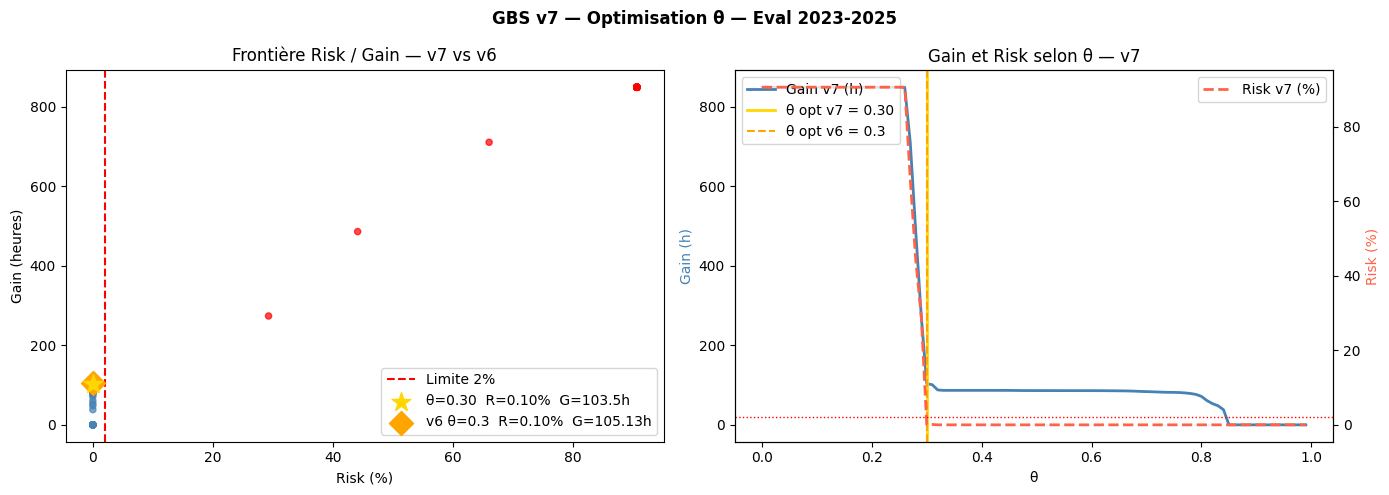

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : frontière Risk / Gain
colors = ['red' if r >= R_MAX else 'steelblue' for r in sweep_df['Risk']]
axes[0].scatter(sweep_df['Risk'] * 100, sweep_df['Gain_h'], c=colors, s=20, alpha=0.7)
axes[0].axvline(R_MAX * 100, color='red', ls='--', lw=1.5, label='Limite 2%')
axes[0].scatter([R_opt*100], [G_opt], color='gold', s=200, zorder=5, marker='*',
                label=f'θ={theta_opt:.2f}  R={R_opt*100:.2f}%  G={G_opt:.1f}h')
# Ref v6
axes[0].scatter([V6_RISK], [V6_GAIN], color='orange', s=150, zorder=4, marker='D',
                label=f'v6 θ={V6_THETA}  R={V6_RISK:.2f}%  G={V6_GAIN}h')
axes[0].set_xlabel('Risk (%)'); axes[0].set_ylabel('Gain (heures)')
axes[0].set_title('Frontière Risk / Gain — v7 vs v6'); axes[0].legend()

# Droite : Gain et Risk vs θ
axes[1].plot(sweep_df['theta'], sweep_df['Gain_h'], 'steelblue', lw=2, label='Gain v7 (h)')
ax2r = axes[1].twinx()
ax2r.plot(sweep_df['theta'], sweep_df['Risk'] * 100, 'tomato', lw=2, ls='--', label='Risk v7 (%)')
ax2r.axhline(R_MAX * 100, color='red', ls=':', lw=1)
axes[1].axvline(theta_opt, color='gold', lw=2, label=f'θ opt v7 = {theta_opt:.2f}')
axes[1].axvline(V6_THETA, color='orange', lw=1.5, ls='--', label=f'θ opt v6 = {V6_THETA}')
axes[1].set_xlabel('θ'); axes[1].set_ylabel('Gain (h)', color='steelblue')
ax2r.set_ylabel('Risk (%)', color='tomato')
axes[1].set_title('Gain et Risk selon θ — v7')
axes[1].legend(loc='upper left'); ax2r.legend(loc='upper right')

plt.suptitle('GBS v7 — Optimisation θ — Eval 2023-2025', fontweight='bold')
plt.tight_layout()
Path('../results').mkdir(exist_ok=True)
plt.savefig('../results/gain_risk_eval_2023_v7.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Détail par aéroport + alertes manquées

In [11]:
above_opt   = df[df['score_conf'] > theta_opt]
t_preds_opt = (
    above_opt.groupby('airport_alert_id')['t_hat']
    .min().reset_index()
    .rename(columns={'t_hat': 't_pred'})
)
res = alert_info.merge(t_preds_opt, on='airport_alert_id', how='left')
res['t_pred']     = res['t_pred'].fillna(res['t_baseline'])
res['gain_min']   = (res['t_baseline'] - res['t_pred']).dt.total_seconds().clip(lower=0) / 60
res['model_used'] = res['airport_alert_id'].isin(above_opt['airport_alert_id'].unique())

d = danger_df.merge(res[['airport_alert_id', 't_pred']], on='airport_alert_id', how='left')
d['missed'] = d['date'] >= d['t_pred']
missed_pa   = d[d['missed']].groupby('airport_alert_id').size().reset_index(name='n_missed')
res = res.merge(missed_pa, on='airport_alert_id', how='left')
res['n_missed'] = res['n_missed'].fillna(0).astype(int)
res['is_risky'] = res['n_missed'] > 0

print(f'θ = {theta_opt:.2f}')
print(f'Alertes avec modèle actif : {res["model_used"].sum():,}')
print(f'Alertes fallback 30 min   : {(~res["model_used"]).sum():,}')
print(f'Alertes RISQUÉES (miss)   : {res["is_risky"].sum():,}')
print(f'Gain moyen                : {res["gain_min"].mean():.2f} min/alerte')

θ = 0.30
Alertes avec modèle actif : 967
Alertes fallback 30 min   : 385
Alertes RISQUÉES (miss)   : 1
Gain moyen                : 4.59 min/alerte


In [12]:
by_ap = res.groupby('airport').agg(
    n_alertes    = ('airport_alert_id', 'count'),
    gain_h       = ('gain_min', lambda x: x.sum() / 60),
    gain_moy_min = ('gain_min', 'mean'),
    n_L3_tot     = ('n_L3', 'sum'),
    n_missed_tot = ('n_missed', 'sum'),
    n_risky      = ('is_risky', 'sum'),
).round(2)
by_ap['Risk_local_%'] = (by_ap['n_missed_tot'] / by_ap['n_L3_tot'].clip(lower=1) * 100).round(2)

print('=== DÉTAIL PAR AÉROPORT — v7 ===')
print(by_ap.to_string())

print('\n=== ALERTES RISQUÉES ===')
alertes_risquees = res[res['is_risky']].sort_values('n_missed', ascending=False)
if len(alertes_risquees):
    print(alertes_risquees[['airport','airport_alert_id','n_strikes','n_L3','n_missed','gain_min','dist_min']].to_string())
else:
    print('Aucune alerte dangereuse manquée !')

print(f'\n=== GLOBAL ===')
print(f'Gain total  : {res["gain_min"].sum()/60:.2f} heures')
print(f'Gain moyen  : {res["gain_min"].mean():.2f} min/alerte')
print(f'Risk global : {M_opt}/{N_L3} = {R_opt*100:.2f}%')

=== DÉTAIL PAR AÉROPORT — v7 ===
          n_alertes  gain_h  gain_moy_min  n_L3_tot  n_missed_tot  n_risky  Risk_local_%
airport                                                                                 
Ajaccio         256   20.95          4.91       142             2        1          1.41
Bastia          322   25.19          4.69       590             0        0          0.00
Biarritz        313   23.67          4.54       443             0        0          0.00
Nantes          122    7.89          3.88       121             0        0          0.00
Pise            339   25.84          4.57       699             0        0          0.00

=== ALERTES RISQUÉES ===
     airport airport_alert_id  n_strikes  n_L3  n_missed  gain_min  dist_min
171  Ajaccio      Ajaccio_835         62     3         2      62.6  1.082823

=== GLOBAL ===
Gain total  : 103.54 heures
Gain moyen  : 4.59 min/alerte
Risk global : 2/1995 = 0.10%


## 7. Sauvegarde

In [13]:
Path('../results').mkdir(exist_ok=True)

# ── 1. Résumé par alerte (jury) ───────────────────────────────────
res.to_csv('../results/predictions_eval_2023_v7.csv', index=False)

# ── 2. Base complète strike par strike ───────────────────────────
cols_base = ['airport', 'airport_alert_id', 'date', 'dist', 'amplitude',
             'airport_enc', 'score_conf', 't_star', 't_hat']
cols_base = [c for c in cols_base if c in df.columns]

df_strikes = df[cols_base].copy()
df_strikes['is_L3']    = df_strikes['dist'] < DIST_3KM
df_strikes['confiant'] = df_strikes['score_conf'] > theta_opt

df_strikes = df_strikes.merge(
    res[['airport_alert_id', 't_pred', 'gain_min', 'n_missed', 'is_risky']],
    on='airport_alert_id', how='left'
)
df_strikes['missed_strike'] = (
    df_strikes['is_L3'] & (df_strikes['date'] >= df_strikes['t_pred'])
)

df_strikes.to_csv('../results/strikes_eval_2023_v7.csv', index=False)

# ── 3. JSON jury ──────────────────────────────────────────────────
jury = {
    'model': 'GBS_v7',
    'eval_set': '2023-2025',
    'n_strikes': len(df),
    'n_alerts': n_alerts,
    'N_L3': N_L3,
    'theta_opt': theta_opt,
    'c_index_train': meta['c_index_train'],
    'c_index_test':  meta['c_index_test'],
    'Risk_pct': round(R_opt * 100, 4),
    'M_L3': M_opt,
    'Gain_h': round(G_opt, 2),
    'Gain_moy_min': round(res['gain_min'].mean(), 2),
    'vs_v6': {
        'delta_risk_pct': round(R_opt*100 - V6_RISK, 4),
        'delta_gain_h':   round(G_opt - V6_GAIN, 2),
    }
}
with open('../results/jury_summary_eval_2023_v7.json', 'w') as f:
    json.dump(jury, f, indent=2)

print('Fichiers sauvegardés :')
print('  results/predictions_eval_2023_v7.csv     ← résumé par alerte')
print('  results/strikes_eval_2023_v7.csv         ← base complète strike par strike')
print('  results/jury_summary_eval_2023_v7.json   ← métriques jury')
print(f'\n  {len(df_strikes):,} strikes | {df_strikes["confiant"].sum():,} confiants | {df_strikes["missed_strike"].sum()} manqués L3')
print()
print(json.dumps(jury, indent=2))

Fichiers sauvegardés :
  results/predictions_eval_2023_v7.csv     ← résumé par alerte
  results/strikes_eval_2023_v7.csv         ← base complète strike par strike
  results/jury_summary_eval_2023_v7.json   ← métriques jury

  80,186 strikes | 1,006 confiants | 2 manqués L3

{
  "model": "GBS_v7",
  "eval_set": "2023-2025",
  "n_strikes": 80186,
  "n_alerts": 1352,
  "N_L3": 1995,
  "theta_opt": 0.3,
  "c_index_train": 0.7755504084704946,
  "c_index_test": 0.7420505663401884,
  "Risk_pct": 0.1003,
  "M_L3": 2,
  "Gain_h": 103.54,
  "Gain_moy_min": 4.59,
  "vs_v6": {
    "delta_risk_pct": 0.0003,
    "delta_gain_h": -1.59
  }
}
